Name: Rujuta Bhanose
PRN: 22311432
Roll No: 381042
Batch: P1

In [1]:
! pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-12.1.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('housing_price_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 6)

First 5 rows:
   avg_area_income  avg_area_house_age  avg_area_rooms  avg_area_bedrooms  \
0     63708.610696            5.332393        4.831940           4.690812   
1    115564.287577           11.754217        4.728852           5.186726   
2     95879.454763           17.713025        9.343782           3.001872   
3     83879.263578           15.180048        4.746823           4.499496   
4     44041.677640           16.518101        4.903648           4.286984   

   area_population          price  
0     30739.814523  368325.525944  
1     41244.454818  512775.271528  
2     39207.241841  721280.953488  
3     11925.495711  628966.744695  
4     11716.226138  531558.113223  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   avg_area_income     1000 non-null   float64
 1   avg_area_house_age  

In [4]:
# Handle missing values (if any) by filling with mean
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        mean_value = df_clean[col].mean()
        df_clean[col].fillna(mean_value, inplace=True)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

# Separate features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# Normalize features using StandardScaler
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print("\nFeatures normalized successfully!")
print("Feature columns:", list(X.columns))

Missing values after imputation:
avg_area_income       0
avg_area_house_age    0
avg_area_rooms        0
avg_area_bedrooms     0
area_population       0
price                 0
dtype: int64

Features normalized successfully!
Feature columns: ['avg_area_income', 'avg_area_house_age', 'avg_area_rooms', 'avg_area_bedrooms', 'area_population']


In [5]:
# Configuration
NUM_CLIENTS = 5  # Number of participating devices/nodes
TEST_SIZE = 0.2  # Holdout test set at server

# Split data into train and test (test remains at server for evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=TEST_SIZE, random_state=42
)

print(f"Total training samples: {len(X_train)}")
print(f"Total test samples: {len(X_test)}")

# Shuffle and split training data among clients
np.random.seed(42)
indices = np.random.permutation(len(X_train))
client_indices = np.array_split(indices, NUM_CLIENTS)

# Create client datasets (each client gets its own private data)
client_datasets = []
for i, idx in enumerate(client_indices):
    client_X = X_train.iloc[idx].reset_index(drop=True)
    client_y = y_train.iloc[idx].reset_index(drop=True)
    client_datasets.append((client_X, client_y))
    print(f"Client {i+1}: {len(client_X)} samples")

# Save client datasets to separate CSV files (simulating distributed storage)
CLIENT_DATA_DIR = "federated_clients_data"
os.makedirs(CLIENT_DATA_DIR, exist_ok=True)

for i, (client_X, client_y) in enumerate(client_datasets, start=1):
    client_df = client_X.copy()
    client_df['price'] = client_y
    client_path = os.path.join(CLIENT_DATA_DIR, f"client_{i}_data.csv")
    client_df.to_csv(client_path, index=False)
    print(f"Saved: {client_path}")

Total training samples: 800
Total test samples: 200
Client 1: 160 samples
Client 2: 160 samples
Client 3: 160 samples
Client 4: 160 samples
Client 5: 160 samples
Saved: federated_clients_data/client_1_data.csv
Saved: federated_clients_data/client_2_data.csv
Saved: federated_clients_data/client_3_data.csv
Saved: federated_clients_data/client_4_data.csv
Saved: federated_clients_data/client_5_data.csv


In [6]:
class LinearRegressionModel:
    """Simple Linear Regression model for federated learning"""
    
    def __init__(self, n_features):
        self.n_features = n_features
        # Initialize weights and bias with small random values
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
    
    def predict(self, X):
        """Make predictions"""
        return np.dot(X, self.weights) + self.bias
    
    def compute_loss(self, X, y):
        """Compute Mean Squared Error loss"""
        predictions = self.predict(X)
        return np.mean((predictions - y) ** 2)
    
    def get_parameters(self):
        """Get model parameters"""
        return {'weights': self.weights.copy(), 'bias': self.bias}
    
    def set_parameters(self, params):
        """Set model parameters"""
        self.weights = params['weights'].copy()
        self.bias = params['bias']
    
    def train_step(self, X, y, learning_rate=0.01):
        """Single training step using gradient descent"""
        n_samples = len(X)
        
        # Forward pass
        predictions = self.predict(X)
        
        # Compute gradients
        error = predictions - y
        weight_gradient = (2 / n_samples) * np.dot(X.T, error)
        bias_gradient = (2 / n_samples) * np.sum(error)
        
        # Update parameters
        self.weights -= learning_rate * weight_gradient
        self.bias -= learning_rate * bias_gradient
        
        return self.compute_loss(X, y)

print("Linear Regression Model class defined!")

Linear Regression Model class defined!


In [7]:
def train_client_model(client_X, client_y, global_params, local_epochs=5, learning_rate=0.01):
    """
    Train a local model on client's private data
    
    Args:
        client_X: Client's feature data
        client_y: Client's target data
        global_params: Global model parameters from server
        local_epochs: Number of local training epochs
        learning_rate: Learning rate for gradient descent
    
    Returns:
        Updated local model parameters and training loss
    """
    n_features = client_X.shape[1]
    
    # Initialize local model with global parameters
    local_model = LinearRegressionModel(n_features)
    local_model.set_parameters(global_params)
    
    # Train locally for specified epochs
    losses = []
    for epoch in range(local_epochs):
        loss = local_model.train_step(
            client_X.values, 
            client_y.values, 
            learning_rate
        )
        losses.append(loss)
    
    # Return updated parameters (NOT raw data - preserving privacy!)
    return local_model.get_parameters(), losses[-1], len(client_X)

print("Client training function defined!")

Client training function defined!


In [8]:
def federated_averaging(client_params_list, client_weights):
    """
    Aggregate client model parameters using weighted averaging (FedAvg algorithm)
    
    Args:
        client_params_list: List of parameter dictionaries from all clients
        client_weights: List of weights for each client (typically number of samples)
    
    Returns:
        Aggregated global model parameters
    """
    total_weight = sum(client_weights)
    
    # Initialize aggregated parameters
    aggregated_params = {
        'weights': np.zeros_like(client_params_list[0]['weights']),
        'bias': 0.0
    }
    
    # Weighted average of all client parameters
    for params, weight in zip(client_params_list, client_weights):
        aggregated_params['weights'] += (weight / total_weight) * params['weights']
        aggregated_params['bias'] += (weight / total_weight) * params['bias']
    
    return aggregated_params

print("Federated Averaging (FedAvg) function defined!")

Federated Averaging (FedAvg) function defined!


In [9]:
def evaluate_global_model(global_params, X_test, y_test):
    """
    Evaluate global model on test data at server
    
    Args:
        global_params: Global model parameters
        X_test: Test features
        y_test: Test targets
    
    Returns:
        Dictionary with evaluation metrics
    """
    n_features = X_test.shape[1]
    model = LinearRegressionModel(n_features)
    model.set_parameters(global_params)
    
    # Make predictions
    predictions = model.predict(X_test.values)
    
    # Compute metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2_score': r2
    }

print("Evaluation function defined!")

Evaluation function defined!


In [10]:
# Federated Learning Configuration
NUM_ROUNDS = 20  # Number of federated learning rounds
LOCAL_EPOCHS = 5  # Number of epochs each client trains locally
LEARNING_RATE = 0.01

# Initialize global model
n_features = X_train.shape[1]
global_model = LinearRegressionModel(n_features)
global_params = global_model.get_parameters()

# Storage for tracking progress
history = {
    'round': [],
    'train_loss': [],
    'test_mse': [],
    'test_rmse': [],
    'test_mae': [],
    'test_r2': []
}

print("=" * 60)
print("FEDERATED LEARNING TRAINING STARTED")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Number of Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print("=" * 60)

# Federated Learning Training Loop
for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    # Step 1: Each client trains locally on its private data
    client_params_list = []
    client_weights_list = []
    round_losses = []
    
    for client_id, (client_X, client_y) in enumerate(client_datasets, start=1):
        # Client trains locally without sharing raw data
        updated_params, loss, n_samples = train_client_model(
            client_X, 
            client_y, 
            global_params,
            local_epochs=LOCAL_EPOCHS,
            learning_rate=LEARNING_RATE
        )
        
        client_params_list.append(updated_params)
        client_weights_list.append(n_samples)
        round_losses.append(loss)
        
        print(f"  Client {client_id}: Loss = {loss:.2f}, Samples = {n_samples}")
    
    # Step 2: Server aggregates client parameters using FedAvg
    global_params = federated_averaging(client_params_list, client_weights_list)
    avg_train_loss = np.mean(round_losses)
    
    # Step 3: Evaluate global model on server's test set
    metrics = evaluate_global_model(global_params, X_test, y_test)
    
    # Store results
    history['round'].append(round_num)
    history['train_loss'].append(avg_train_loss)
    history['test_mse'].append(metrics['mse'])
    history['test_rmse'].append(metrics['rmse'])
    history['test_mae'].append(metrics['mae'])
    history['test_r2'].append(metrics['r2_score'])
    
    print(f"\n  → Average Train Loss: {avg_train_loss:.2f}")
    print(f"  → Test RMSE: {metrics['rmse']:.2f}")
    print(f"  → Test MAE: {metrics['mae']:.2f}")
    print(f"  → Test R² Score: {metrics['r2_score']:.4f}")

print("\n" + "=" * 60)
print("FEDERATED LEARNING TRAINING COMPLETED!")
print("=" * 60)

FEDERATED LEARNING TRAINING STARTED
Number of Clients: 5
Number of Rounds: 20
Local Epochs per Round: 5
Learning Rate: 0.01

ROUND 1/20
  Client 1: Loss = 244782121547.86, Samples = 160
  Client 2: Loss = 238334744645.60, Samples = 160
  Client 3: Loss = 245838813889.18, Samples = 160
  Client 4: Loss = 248503092050.05, Samples = 160
  Client 5: Loss = 251921293585.52, Samples = 160

  → Average Train Loss: 245876013143.64
  → Test RMSE: 484758.85
  → Test MAE: 473314.44
  → Test R² Score: -16.3908

ROUND 2/20
  Client 1: Loss = 199830561998.74, Samples = 160
  Client 2: Loss = 194763861315.55, Samples = 160
  Client 3: Loss = 200458216155.66, Samples = 160
  Client 4: Loss = 202987161639.57, Samples = 160
  Client 5: Loss = 205590483217.03, Samples = 160

  → Average Train Loss: 200726056865.31
  → Test RMSE: 438814.81
  → Test MAE: 428449.53
  → Test R² Score: -13.2505

ROUND 3/20
  Client 1: Loss = 163230505546.57, Samples = 160
  Client 2: Loss = 159261096900.48, Samples = 160
  Cl

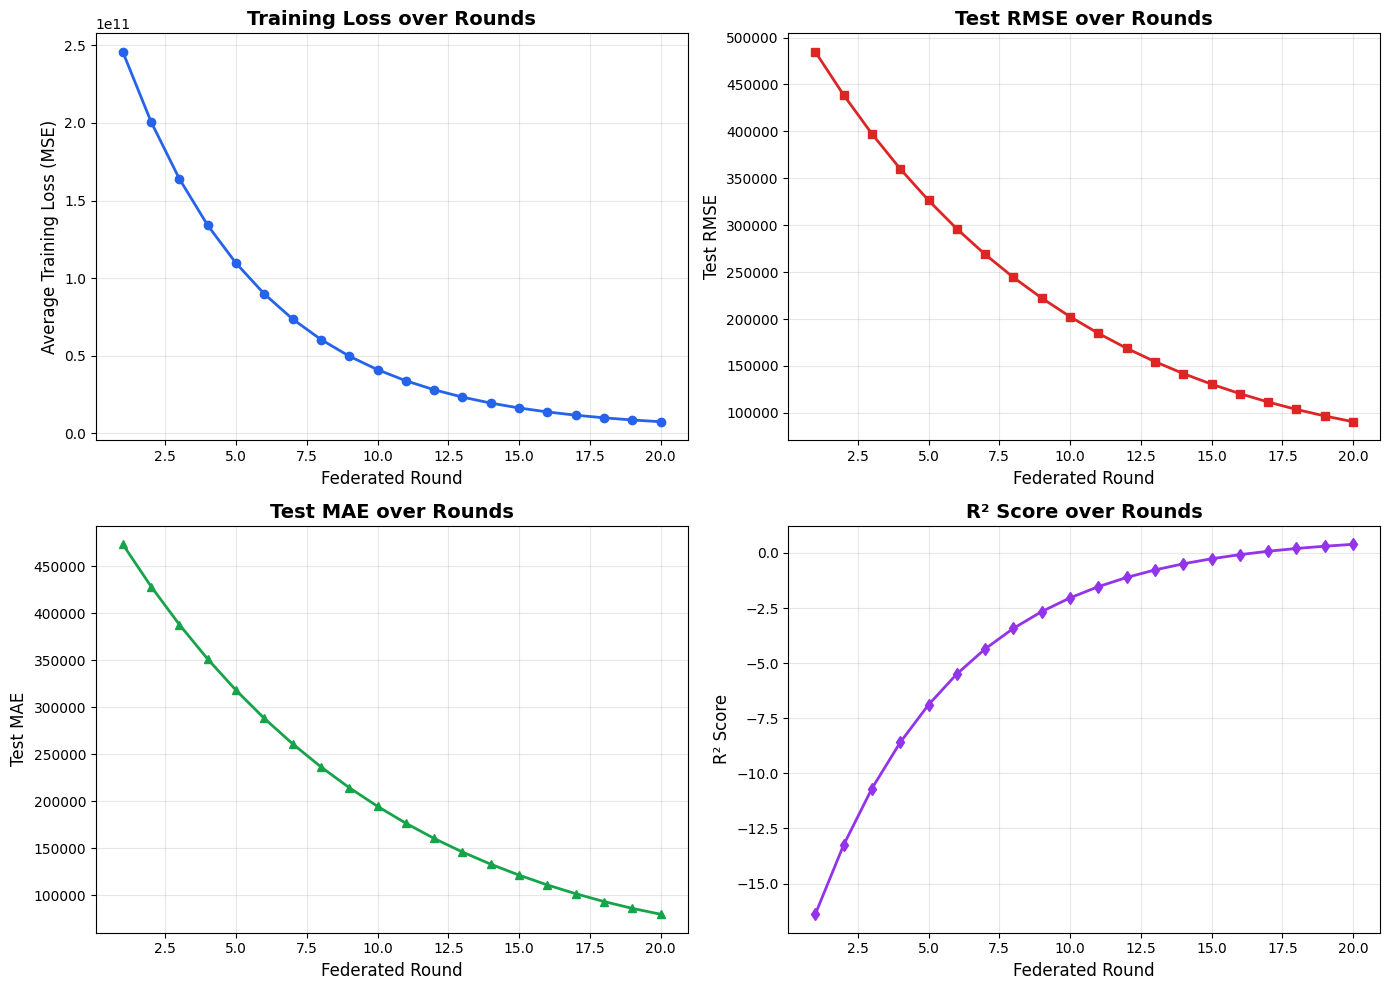

Visualization saved as 'federated_learning_results.png'


In [11]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Training Loss
axes[0, 0].plot(history['round'], history['train_loss'], 
                marker='o', linewidth=2, color='#2563eb')
axes[0, 0].set_xlabel('Federated Round', fontsize=12)
axes[0, 0].set_ylabel('Average Training Loss (MSE)', fontsize=12)
axes[0, 0].set_title('Training Loss over Rounds', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Test RMSE
axes[0, 1].plot(history['round'], history['test_rmse'], 
                marker='s', linewidth=2, color='#dc2626')
axes[0, 1].set_xlabel('Federated Round', fontsize=12)
axes[0, 1].set_ylabel('Test RMSE', fontsize=12)
axes[0, 1].set_title('Test RMSE over Rounds', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Test MAE
axes[1, 0].plot(history['round'], history['test_mae'], 
                marker='^', linewidth=2, color='#16a34a')
axes[1, 0].set_xlabel('Federated Round', fontsize=12)
axes[1, 0].set_ylabel('Test MAE', fontsize=12)
axes[1, 0].set_title('Test MAE over Rounds', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: R² Score
axes[1, 1].plot(history['round'], history['test_r2'], 
                marker='d', linewidth=2, color='#9333ea')
axes[1, 1].set_xlabel('Federated Round', fontsize=12)
axes[1, 1].set_ylabel('R² Score', fontsize=12)
axes[1, 1].set_title('R² Score over Rounds', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('federated_learning_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'federated_learning_results.png'")

In [12]:
# Final evaluation
final_metrics = evaluate_global_model(global_params, X_test, y_test)

print("\n" + "=" * 60)
print("FINAL GLOBAL MODEL PERFORMANCE")
print("=" * 60)
print(f"Mean Squared Error (MSE):  {final_metrics['mse']:.2f}")
print(f"Root Mean Squared Error (RMSE): {final_metrics['rmse']:.2f}")
print(f"Mean Absolute Error (MAE): {final_metrics['mae']:.2f}")
print(f"R² Score: {final_metrics['r2_score']:.4f}")
print("=" * 60)

# Display model parameters
print("\nGlobal Model Parameters:")
print(f"Weights: {global_params['weights']}")
print(f"Bias: {global_params['bias']:.2f}")

# Sample predictions
print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS (First 10 test samples)")
print("=" * 60)

global_model.set_parameters(global_params)
sample_predictions = global_model.predict(X_test.values[:10])

comparison_df = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': sample_predictions,
    'Absolute Error': np.abs(y_test.values[:10] - sample_predictions)
})

print(comparison_df.to_string(index=True))
print("=" * 60)


FINAL GLOBAL MODEL PERFORMANCE
Mean Squared Error (MSE):  8204507282.60
Root Mean Squared Error (RMSE): 90578.74
Mean Absolute Error (MAE): 79804.33
R² Score: 0.3928

Global Model Parameters:
Weights: [60565.52430306 73573.84809473 36563.60966821  6107.65120877
   870.23105084]
Bias: 462133.61

SAMPLE PREDICTIONS (First 10 test samples)
    Actual Price  Predicted Price  Absolute Error
0  634210.439769    500615.797648   133594.642121
1  550472.114473    461540.827719    88931.286753
2  692130.771424    529466.407608   162664.363816
3  609549.222892    454556.443907   154992.778985
4  372812.404494    403259.544951    30447.140457
5  492751.345715    435519.401794    57231.943921
6  438416.340196    316342.305294   122074.034902
7  519940.920388    425322.005134    94618.915254
8  473952.018120    397207.295766    76744.722354
9  571866.097592    507626.044049    64240.053544


In [13]:
# Save training history to CSV
history_df = pd.DataFrame(history)
history_df.to_csv('federated_learning_history.csv', index=False)
print("Training history saved to 'federated_learning_history.csv'")

# Display summary
print("\nTraining History Summary:")
print(history_df.to_string(index=False))

Training history saved to 'federated_learning_history.csv'

Training History Summary:
 round   train_loss     test_mse     test_rmse      test_mae    test_r2
     1 2.458760e+11 2.349911e+11 484758.845715 473314.440030 -16.390829
     2 2.007261e+11 1.925584e+11 438814.811554 428449.529629 -13.250541
     3 1.639628e+11 1.579238e+11 397396.304922 387894.251599 -10.687361
     4 1.340260e+11 1.296488e+11 360067.811046 351233.826739  -8.594832
     5 1.096462e+11 1.065610e+11 326436.897109 318093.471343  -6.886191
     6 8.979036e+10 8.770481e+10 296149.985894 288134.533567  -5.490710
     7 7.361760e+10 7.230104e+10 268888.534848 261051.003681  -4.350734
     8 6.044372e+10 5.971454e+10 244365.576771 236566.361977  -3.419253
     9 4.971176e+10 4.942733e+10 222322.581975 214437.600902  -2.657935
    10 4.096835e+10 4.101703e+10 202526.605204 194572.875248  -2.035519
    11 3.384444e+10 3.413910e+10 184767.683888 176613.647870  -1.526509
    12 2.803957e+10 2.851250e+10 168856.457729 160